CUSTOMER REVIEW SENTIMENT CLASSIFICATION USING SVM

Dataset created successfully!
Total Reviews: 96

Sentiment Distribution:
Sentiment
Positive    48
Negative    48
Name: count, dtype: int64

Data preprocessing completed!

Training Reviews: 76
Testing Reviews: 20

TF-IDF conversion completed!
SVM model trained successfully!

Actual Sentiments:
['Positive', 'Positive', 'Positive', 'Positive', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Positive', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Positive']

Predicted Sentiments:
['Positive', 'Positive', 'Positive', 'Positive', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Positive', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Positive']

MODEL EVALUATION

Accuracy: 1.0
Accuracy Percentage: 100.0 %

Classification Report:
              precision    recall  f1-score   support

    Nega

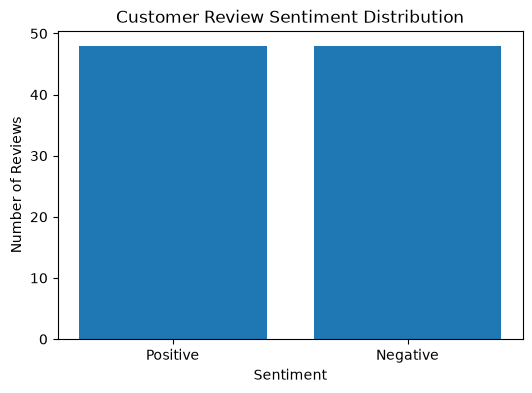

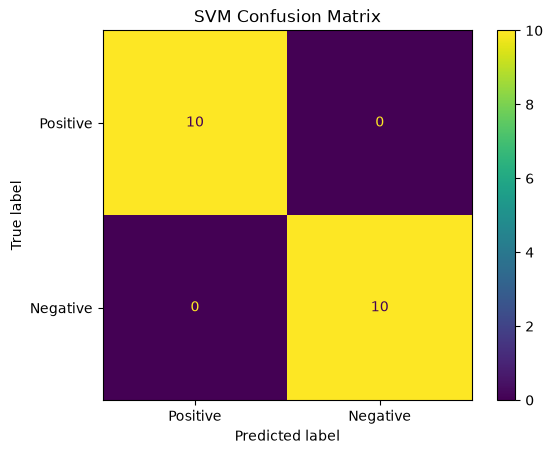


NEW REVIEW PREDICTIONS

Review: excellent quality product
Predicted Sentiment: Positive

Review: terrible quality product
Predicted Sentiment: Negative

Review: very good service
Predicted Sentiment: Positive

Review: worst service
Predicted Sentiment: Negative

PROJECT COMPLETED SUCCESSFULLY


In [2]:
# ============================================================
# CUSTOMER REVIEW SENTIMENT CLASSIFICATION USING SVM
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -------------------- 1. DATASET --------------------

positive_reviews = [
    "excellent product quality",
    "amazing product quality",
    "very good product",
    "wonderful product",
    "great product",
    "fantastic product",
    "perfect product",
    "awesome product",
    "excellent service",
    "amazing service",
    "very good service",
    "wonderful service",
    "great service",
    "fantastic service",
    "perfect service",
    "awesome service",
    "excellent purchase",
    "amazing purchase",
    "very good purchase",
    "wonderful purchase",
    "great purchase",
    "fantastic purchase",
    "perfect purchase",
    "awesome purchase",
    "excellent experience",
    "amazing experience",
    "very good experience",
    "wonderful experience",
    "great experience",
    "fantastic experience",
    "perfect experience",
    "awesome experience",
    "excellent quality",
    "amazing quality",
    "very good quality",
    "wonderful quality",
    "great quality",
    "fantastic quality",
    "perfect quality",
    "awesome quality",
    "excellent value",
    "amazing value",
    "very good value",
    "wonderful value",
    "great value",
    "fantastic value",
    "perfect value",
    "awesome value"
]

negative_reviews = [
    "terrible product quality",
    "worst product quality",
    "very bad product",
    "awful product",
    "poor product",
    "horrible product",
    "useless product",
    "disappointing product",
    "terrible service",
    "worst service",
    "very bad service",
    "awful service",
    "poor service",
    "horrible service",
    "useless service",
    "disappointing service",
    "terrible purchase",
    "worst purchase",
    "very bad purchase",
    "awful purchase",
    "poor purchase",
    "horrible purchase",
    "useless purchase",
    "disappointing purchase",
    "terrible experience",
    "worst experience",
    "very bad experience",
    "awful experience",
    "poor experience",
    "horrible experience",
    "useless experience",
    "disappointing experience",
    "terrible quality",
    "worst quality",
    "very bad quality",
    "awful quality",
    "poor quality",
    "horrible quality",
    "useless quality",
    "disappointing quality",
    "terrible value",
    "worst value",
    "very bad value",
    "awful value",
    "poor value",
    "horrible value",
    "useless value",
    "disappointing value"
]

reviews = positive_reviews + negative_reviews
sentiments = (
    ["Positive"] * len(positive_reviews)
    + ["Negative"] * len(negative_reviews)
)

df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": sentiments
})

print("=" * 60)
print("CUSTOMER REVIEW SENTIMENT CLASSIFICATION USING SVM")
print("=" * 60)

print("\nDataset created successfully!")
print("Total Reviews:", len(df))

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

# -------------------- 2. DATA PREPROCESSING --------------------

df["Review"] = df["Review"].str.lower()

print("\nData preprocessing completed!")

# -------------------- 3. TRAIN TEST SPLIT --------------------

X = df["Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Reviews:", len(X_train))
print("Testing Reviews:", len(X_test))

# -------------------- 4. TF-IDF --------------------

vectorizer = TfidfVectorizer(ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF conversion completed!")

# -------------------- 5. SVM MODEL --------------------

model = SVC(kernel="linear")

model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

# -------------------- 6. PREDICTION --------------------

y_pred = model.predict(X_test_tfidf)

print("\nActual Sentiments:")
print(list(y_test))

print("\nPredicted Sentiments:")
print(list(y_pred))

# -------------------- 7. ACCURACY --------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# -------------------- 8. CLASSIFICATION REPORT --------------------

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -------------------- 9. CONFUSION MATRIX VALUES --------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Positive", "Negative"]
)

print("Confusion Matrix:")
print(cm)

# -------------------- 10. GRAPH 1 --------------------

plt.figure(figsize=(6, 4))

sentiment_counts = df["Sentiment"].value_counts()

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Customer Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

# -------------------- 11. GRAPH 2 --------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Positive", "Negative"]
)

disp.plot()

plt.title("SVM Confusion Matrix")
plt.show()

# -------------------- 12. NEW REVIEW PREDICTION --------------------

new_reviews = [
    "excellent quality product",
    "terrible quality product",
    "very good service",
    "worst service"
]

new_reviews_tfidf = vectorizer.transform(new_reviews)
new_predictions = model.predict(new_reviews_tfidf)

print("\n" + "=" * 60)
print("NEW REVIEW PREDICTIONS")
print("=" * 60)

for review, prediction in zip(new_reviews, new_predictions):
    print("\nReview:", review)
    print("Predicted Sentiment:", prediction)

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)